In [87]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings("ignore")

In [88]:
from sklearn.datasets import make_regression

In [89]:
x,y = make_regression(n_samples=1000,n_features=2,n_targets=1,noise=3)  # noise means 3 outliers

In [90]:
x

array([[-0.04038523,  0.67597781],
       [-1.02295181, -0.29210039],
       [-1.26582066,  0.60636091],
       ...,
       [-1.22961213, -1.47166047],
       [ 0.53308039,  0.8205143 ],
       [ 1.07649408,  0.09035601]])

In [91]:
y

array([ 3.76279250e+01, -2.66714294e+01,  2.59741825e+01, -7.39784416e+01,
        5.13347998e+01,  8.73603620e+01,  7.39338350e+01, -3.82185874e+01,
        4.72120002e+01,  9.06022329e+01, -1.66601674e+01, -5.16034531e+01,
       -5.84304458e+01,  4.49469135e+01,  6.41065559e+01,  3.21568599e+01,
       -1.81148018e+02, -3.68724931e+01, -1.58927807e+01, -6.45810977e+01,
       -7.33446235e+01, -1.18632539e+01, -2.79528287e+01,  2.17744669e+01,
       -8.14438721e+01,  5.43569705e+01, -5.93806886e+01,  1.77508034e+01,
       -7.86827084e+01,  7.64133621e+01, -1.84067451e+01, -8.66059439e+00,
       -2.19091816e+01, -6.12246899e+00,  1.04401845e+01,  4.51995242e+01,
        2.10174469e+01, -4.14406481e+01, -5.40307608e+01,  1.62466493e+01,
        1.13651020e+01,  1.50805674e+01, -1.65864831e+01, -9.57651861e+01,
       -9.52239367e+01,  4.93697163e+01,  4.01980368e+01,  3.67593104e+01,
       -1.40254563e+01, -4.89287231e+01,  2.39086256e+01, -1.89662380e+01,
       -4.41099862e+01,  

In [92]:
pd.DataFrame(x)[0]

0     -0.040385
1     -1.022952
2     -1.265821
3      1.131063
4      1.203846
         ...   
995   -0.394549
996   -0.564782
997   -1.229612
998    0.533080
999    1.076494
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

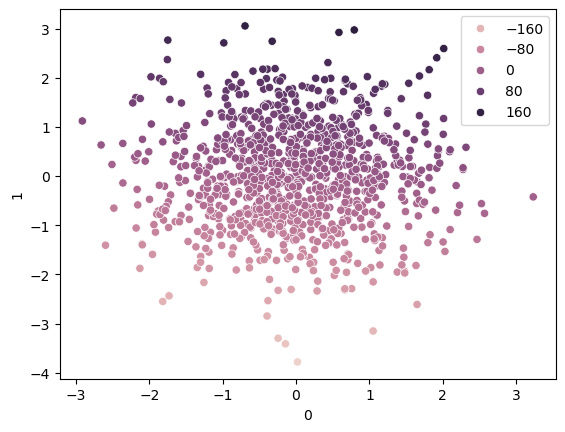

In [93]:
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)


In [94]:
from sklearn.model_selection import train_test_split

In [95]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.20,random_state=1)

In [96]:
from sklearn.svm import SVR

In [97]:
svr = SVR(kernel="linear")

In [98]:
svr.fit(x_train , y_train )

SVR(kernel='linear')

In [99]:
y_pred = svr.predict(x_test)

In [100]:
# hyperparameter tunning 
from sklearn.model_selection import GridSearchCV

In [101]:
params = {"C":[1,2,3,10,50,100],"gamma":[1,0.1,0.2,0.001,0.003],"kernel":["linear"],"epsilon":[0.01,0.1,0.2,0.3]}

In [102]:
params

{'C': [1, 2, 3, 10, 50, 100],
 'gamma': [1, 0.1, 0.2, 0.001, 0.003],
 'kernel': ['linear'],
 'epsilon': [0.01, 0.1, 0.2, 0.3]}

In [103]:
gsvr = GridSearchCV(SVR(),param_grid=params,cv = 5,verbose=2)

In [104]:
gsvr.fit(x_train,y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END ..........C=1, epsilon=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END ..........C=1, epsilon=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END ..........C=1, epsilon=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END ..........C=1, epsilon=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END ..........C=1, epsilon=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........C=1, epsilon=0.01, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ........C=1, epsilon=0.01, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ........C=1, epsilon=0.01, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ........C=1, epsilon=0.01, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ........C=1, epsilon=0.01, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ........C=1, epsilon=0.01, gamma=0.2, kernel=linear; total time=   0.0s
[CV] END ........C=1, epsilon=0.01, gamma=0.2,

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 2, 3, 10, 50, 100],
                         'epsilon': [0.01, 0.1, 0.2, 0.3],
                         'gamma': [1, 0.1, 0.2, 0.001, 0.003],
                         'kernel': ['linear']},
             verbose=2)

In [105]:
gsvr.best_params_

{'C': 10, 'epsilon': 0.1, 'gamma': 1, 'kernel': 'linear'}

In [106]:
final_model = gsvr.best_estimator_

In [107]:
y_pred = final_model.predict(x_test)

In [110]:
from sklearn.metrics import accuracy_score , r2_score

In [111]:
r2_score(y_test,y_pred)

0.997164394225838